# LSG50 Backtest

En este notebook evaluamos el rendimiento histórico del índice LSG50
comparándolo contra el S&P 500 como benchmark.

El objetivo es analizar si la metodología basada en el CFO Index
genera un perfil de rendimiento competitivo.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sqlalchemy import create_engine

In [10]:
engine = create_engine("sqlite:///lsg50.db")

In [11]:
df_index = pd.read_sql("""
SELECT symbol, weight
FROM lsg50_composition
WHERE calculation_date = (
    SELECT MAX(calculation_date)
    FROM lsg50_composition
)
""", engine)

df_index.head()

,symbol,weight
0,NVDA,0.023272
1,GE,0.022590
2,LLY,0.022302
3,META,0.022065
4,TMUS,0.021829


In [12]:
tickers = df_index["symbol"].tolist()
weights = df_index.set_index("symbol")["weight"]

print("Constituents:", len(tickers))

Constituents: 150


In [13]:
prices = yf.download(
    tickers=tickers,
    start="2018-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  50 of 50 completed


Ticker,AMD,ANET,APH,AVGO,AXP,BKNG,BSX,CMCSA,COST,CRM,...,ORCL,PGR,PH,TJX,TMUS,V,VLO,WELL,WFC,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,10.98,14.439375,20.342403,21.130898,88.571526,1756.016968,25.280001,31.178972,168.728333,103.156616,...,41.251202,42.759346,176.664444,34.233719,61.573349,108.111916,67.019829,48.156010,48.653313,28.914415
2018-01-03,11.55,14.725000,20.606535,21.361984,89.117615,1794.792603,25.559999,30.677923,170.753235,104.026047,...,42.206612,42.736187,178.105118,33.617710,61.159916,109.188210,67.373726,48.238747,49.027641,29.166632
2018-01-04,12.12,14.543125,20.534706,21.369104,90.599945,1778.154663,25.320000,30.875319,169.427231,105.399368,...,42.622402,42.728447,178.918289,33.671280,60.573402,109.594193,67.590370,47.200867,49.640881,29.193027
2018-01-05,11.88,14.798125,20.784943,21.495728,90.806534,1794.182495,25.969999,31.156206,168.217697,106.802322,...,42.878944,42.890652,180.138077,34.439064,62.111786,112.218849,67.908165,46.907555,49.975380,29.366074
2018-01-08,12.28,15.691250,21.007360,21.547167,89.971062,1821.997559,25.809999,30.731077,168.871704,107.553192,...,43.330132,43.021969,181.675934,33.769485,62.592529,112.672020,68.045387,47.073009,49.409916,29.800116


In [14]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,AMD,ANET,APH,AVGO,AXP,BKNG,BSX,CMCSA,COST,CRM,...,ORCL,PGR,PH,TJX,TMUS,V,VLO,WELL,WFC,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,0.051913,0.019781,0.012984,0.010936,0.006166,0.022082,0.011076,-0.016070,0.012001,0.008428,...,0.023161,-0.000542,0.008155,-0.017994,-0.006714,0.009955,0.005280,0.001718,0.007694,0.008723
2018-01-04,0.049351,-0.012351,-0.003486,0.000333,0.016633,-0.009270,-0.009390,0.006434,-0.007766,0.013202,...,0.009851,-0.000181,0.004566,0.001593,-0.009590,0.003718,0.003216,-0.021515,0.012508,0.000905
2018-01-05,-0.019802,0.017534,0.012186,0.005926,0.002280,0.009014,0.025671,0.009097,-0.007139,0.013311,...,0.006019,0.003796,0.006818,0.022802,0.025397,0.023949,0.004702,-0.006214,0.006738,0.005928
2018-01-08,0.033670,0.060354,0.010701,0.002393,-0.009201,0.015503,-0.006161,-0.013645,0.003888,0.007030,...,0.010522,0.003062,0.008537,-0.019442,0.007740,0.004038,0.002021,0.003527,-0.011315,0.014780
2018-01-09,-0.037459,-0.004302,0.001544,-0.013847,0.003695,0.007279,0.083301,0.003211,-0.011619,0.002664,...,0.005534,0.008438,0.008611,-0.001983,0.007680,-0.001927,-0.001274,-0.019492,0.003546,-0.012006


In [15]:
# Remove duplicate tickers (GOOG / GOOGL issue)

returns = returns.loc[:, ~returns.columns.duplicated()]

weights = weights[~weights.index.duplicated()]

In [16]:
portfolio_returns = (returns * weights).sum(axis=1)

portfolio_returns.head()

Date
2018-01-03    0.009874
2018-01-04    0.004530
2018-01-05    0.007352
2018-01-08    0.005864
2018-01-09    0.002954
dtype: float64

In [17]:
sp500 = yf.download(
    "^GSPC",
    start="2018-01-01",
    auto_adjust=True
)["Close"]

sp500_returns = sp500.pct_change().dropna()

[*********************100%***********************]  1 of 1 completed


In [18]:
portfolio_cum = (1 + portfolio_returns).cumprod()
sp500_cum = (1 + sp500_returns).cumprod()

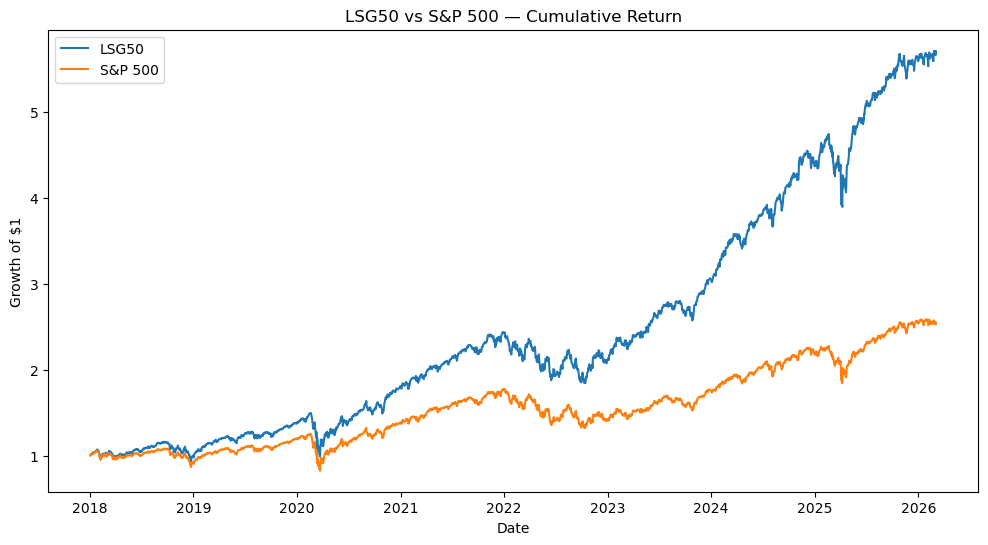

In [19]:
plt.figure(figsize=(12,6))

plt.plot(portfolio_cum, label="LSG50")
plt.plot(sp500_cum, label="S&P 500")

plt.title("LSG50 vs S&P 500 — Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()

plt.savefig("../images/lsg50_vs_sp500.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretación del gráfico: LSG50 vs S&P 500

El gráfico muestra la evolución del crecimiento acumulado de $1 invertido tanto en el índice **LSG50** como en el **S&P 500** desde 2018.

Para construir esta visualización se calcularon primero los **retornos diarios** de cada activo utilizando precios ajustados. A partir de estos retornos se estimó el rendimiento del portafolio LSG50 aplicando los pesos obtenidos en la construcción del índice.

Posteriormente, se calculó el **retorno acumulado** mediante el producto acumulado de:

(1 + retorno diario)

Este procedimiento permite representar cómo evolucionaría una inversión inicial de $1 a lo largo del tiempo.

### Qué muestra el gráfico

- La línea azul representa el crecimiento del índice **LSG50**, construido a partir del ranking de empresas según el **CFO Index**.
- La línea naranja muestra el comportamiento del **S&P 500**, utilizado como benchmark del mercado.

### Interpretación

El gráfico permite evaluar visualmente la capacidad del índice LSG50 para generar **rendimientos superiores al mercado** a lo largo del período analizado.

En este caso se observa que:

- El índice LSG50 presenta un crecimiento acumulado superior al del S&P 500.
- La diferencia se amplía especialmente en los últimos años del período analizado.
- Esto sugiere que la metodología de selección basada en el **CFO Index** podría capturar empresas con características financieras que generan mayor crecimiento en el largo plazo.

### Métricas complementarias

Además del crecimiento acumulado, se calculan métricas adicionales para evaluar el desempeño del índice:

- **Retorno anualizado:** rendimiento promedio del portafolio en términos anuales.
- **Volatilidad anualizada:** variabilidad de los retornos.
- **Sharpe Ratio:** medida de rendimiento ajustado por riesgo.

Estas métricas permiten comparar de forma más rigurosa la eficiencia del índice frente al benchmark.

In [20]:
portfolio_mean = portfolio_returns.mean() * 252
portfolio_vol = portfolio_returns.std() * np.sqrt(252)

sharpe = portfolio_mean / portfolio_vol

print("Annual Return:", portfolio_mean)
print("Volatility:", portfolio_vol)
print("Sharpe Ratio:", sharpe)

Annual Return: 0.2349620936558617
Volatility: 0.205038678313457
Sharpe Ratio: 1.1459403444683673


In [21]:
print("LSG50 tickers:", prices.shape[1])
print("S&P500 series:", len(sp500))

LSG50 tickers: 50
S&P500 series: 2053


## Backtest Results

El índice LSG50 se comparó contra el S&P 500 utilizando datos históricos.

El análisis permite evaluar:

• crecimiento acumulado del portafolio  
• volatilidad  
• ratio de Sharpe  

Este tipo de análisis es estándar en research cuantitativo
para evaluar metodologías de construcción de índices.